**Analisis Sentimen Jersey Erspo Timnas Indonesia Menggunakan Model Klasifikasi dan Algoritma Naïve Bayes**

# **Crawl Data Twitter Tweets Jersey ERSPO**




In [ ]:
#pake auth token twitter

twitter_auth_token = ''

In [ ]:
# Import required Python package
!pip install pandas

# Install Node.js (karena tweet harvest dibuat pake node.js)
!sudo apt-get update
!sudo apt-get install -y ca-certificates curl gnupg
!sudo mkdir -p /etc/apt/keyrings
!curl -fsSL https://deb.nodesource.com/gpgkey/nodesource-repo.gpg.key | sudo gpg --dearmor -o /etc/apt/keyrings/nodesource.gpg

!NODE_MAJOR=20 && echo "deb [signed-by=/etc/apt/keyrings/nodesource.gpg] https://deb.nodesource.com/node_$NODE_MAJOR.x nodistro main" | sudo tee /etc/apt/sources.list.d/nodesource.list

!sudo apt-get update
!sudo apt-get install nodejs -y

!node -v

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [110 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [119 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://ppa.launchpadcontent.net/c2d4u.team/c2d4u4.0+/ubuntu jammy InRelease
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,375 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [2,125 kB]
Fetched 3,733 kB in 1s (2,587 kB/s)
Reading package lists... Do

In [ ]:
# Crawl Data

filename = 'jersey-erspo.csv'
search_keyword = 'jersey timnas lang:id'
limit = 2000

!npx -y tweet-harvest@2.6.1 -o "{filename}" -s "{search_keyword}" --tab "LATEST" -l {limit} --token {twitter_auth_token}

npm WARN deprecated inflight@1.0.6: This module is not supported, and leaks memory. Do not use it. Check out lru-cache if you want a good and tested way to coalesce async requests by a key value, which is much more comprehensive and powerful.
Tweet Harvest [v2.6.1]

Research by Helmi Satria
Use it for Educational Purposes only!

This script uses Chromium Browser to crawl data from Twitter with your Twitter auth token.
Please enter your Twitter auth token when prompted.

Note: Keep your access token secret! Don't share it with anyone else.
Note: This script only runs on your local device.


Opening twitter search page...


Filling in keywords: jersey timnas


-- Scrolling... (1) (2) (3) (4)Created new directory: /content/tweets-data


Your tweets saved to: /content/tweets-data/jersey-erspo.csv
Total tweets saved: 15

-- Scrolling... (1)

Your tweets saved to: /content/tweets-data/jersey-erspo.csv
Total tweets saved: 28

-- Scrolling... (1)

Your tweets saved to: /content/tweets-data/jer

In [ ]:
import pandas as pd

# Specify the path to your CSV file
file_path = f"tweets-data/{filename}"

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(file_path, delimiter=",")

# Display the DataFrame
display(df)

NameError: name 'filename' is not defined

In [ ]:
# Cek jumlah data yang didapatkan

num_tweets = len(df)
print(f"Jumlah tweet dalam dataframe adalah {num_tweets}.")

Jumlah tweet dalam dataframe adalah 1229.


# **Tampilin Setelah Crawling Data**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import nltk
import string
import re



In [ ]:
#baca data file csv ke dalam sebuah DataFrame menggunakan library pandas

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Kecerdasan Buatan/TUBES/jersey-erspo-1230.csv")
df.head(1229)

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1.793900e+18,Fri May 24 06:54:07 +0000 2024,2,Pertama kali beli jersey pabrikan Errea yang n...,1.793900e+18,NaN,NaN,art,Indonesia,0,0,0,https://x.com/Officialkjti/status/179389825277...,1.028640e+18,Officialkjti
1,1.793900e+18,Fri May 24 06:42:16 +0000 2024,4,Pertama kali beli jersey pabrikan Errea yang n...,1.793900e+18,https://pbs.twimg.com/media/GOUyO0BWwAEVvWB.jpg,NaN,in,"Sakarya, Türkiye",1,3,1,https://x.com/avicenna_ryu/status/179389527150...,9.458320e+17,avicenna_ryu
2,1.793890e+18,Fri May 24 06:39:05 +0000 2024,5,Tidak di 3 ini sih kabarnya kan cuma kabar tun...,1.793890e+18,NaN,NaN,in,Indonesia,1,3,0,https://x.com/Officialkjti/status/179389447130...,1.028640e+18,Officialkjti
3,1.793890e+18,Fri May 24 06:33:14 +0000 2024,9,Tapi isunya persib psis trus ada beberapa lagi...,1.793890e+18,NaN,NaN,in,Indonesia,2,4,2,https://x.com/Officialkjti/status/179389300000...,1.028640e+18,Officialkjti
4,1.793890e+18,Fri May 24 06:28:05 +0000 2024,1,Full interview Nunez dengan Por la Jersey: Aku...,1.793890e+18,https://pbs.twimg.com/ext_tw_video_thumb/17933...,NaN,in,Indonesia,0,0,0,https://x.com/minfieldstore/status/17938917023...,2.540793e+09,minfieldstore
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,1.784840e+18,Mon Apr 29 06:52:52 +0000 2024,0,Seumur hidup ga pernah punya jersey timnas bol...,1.784840e+18,NaN,NaN,in,NaN,0,1,0,https://x.com/fazerdewz/status/178483824167554...,2.313832e+08,fazerdewz
1225,1.784610e+18,Mon Apr 29 06:43:16 +0000 2024,0,@MafiaWasit Info sewa jersey timnas buat nobar...,1.784840e+18,https://pbs.twimg.com/media/GMUCuFsbQAAW2GU.jpg,MafiaWasit,in,Indonesia,0,0,0,https://x.com/dennis_pw/status/178483582572293...,4.855426e+08,dennis_pw
1226,1.784830e+18,Mon Apr 29 06:27:24 +0000 2024,0,adakah yang punya info beli jersey timnas ersp...,1.784830e+18,NaN,NaN,in,DKI JAKARTA,0,2,0,https://x.com/lutfielmondo/status/178483183626...,5.134684e+08,lutfielmondo
1227,1.784830e+18,Mon Apr 29 06:19:24 +0000 2024,0,want to buy / wtb / dicari jersey timnas 2022 ...,1.784830e+18,NaN,NaN,in,rant acc,0,2,0,https://x.com/photostrlip/status/1784829820129...,1.511370e+18,photostrlip


# **Cek Data Info**

In [ ]:
#cek data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1229 entries, 0 to 1228
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   conversation_id_str      1229 non-null   float64
 1   created_at               1229 non-null   object 
 2   favorite_count           1229 non-null   int64  
 3   full_text                1229 non-null   object 
 4   id_str                   1229 non-null   float64
 5   image_url                455 non-null    object 
 6   in_reply_to_screen_name  450 non-null    object 
 7   lang                     1229 non-null   object 
 8   location                 669 non-null    object 
 9   quote_count              1229 non-null   int64  
 10  reply_count              1229 non-null   int64  
 11  retweet_count            1229 non-null   int64  
 12  tweet_url                1229 non-null   object 
 13  user_id_str              1229 non-null   float64
 14  username                

# **Summary Data**

In [ ]:
summary = df.describe()
summary.head()

,conversation_id_str,favorite_count,id_str,quote_count,reply_count,retweet_count,user_id_str
count,1.229000e+03,1229.000000,1.229000e+03,1229.000000,1229.000000,1229.000000,1.229000e+03
mean,1.787611e+18,9.638731,1.788324e+18,0.231896,1.873068,1.350692,8.855516e+17
std,1.408597e+16,101.055463,2.621302e+15,2.914765,32.296522,16.837503,6.896647e+17
min,1.380780e+18,0.000000,1.784830e+18,0.000000,0.000000,0.000000,1.712898e+07
25%,1.786090e+18,0.000000,1.786100e+18,0.000000,0.000000,0.000000,1.602931e+09


# **VISUALISASI ORIGINAL DATA WORLDCLOUD & FREKUENSI KATA**

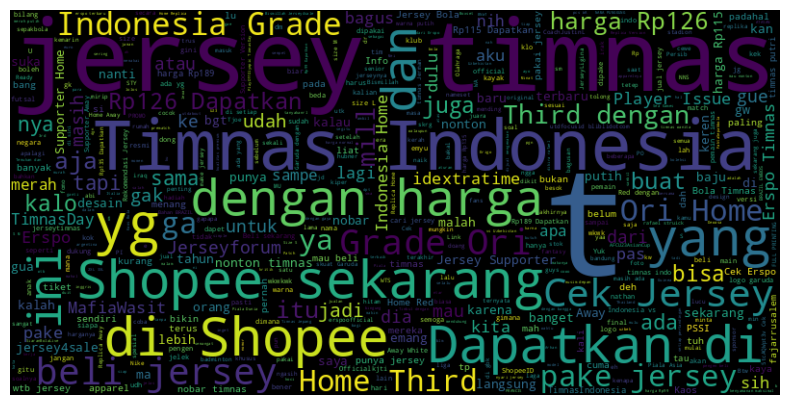

                word  frequency
0                  t   1.000000
1      jersey timnas   0.947856
2   Timnas Indonesia   0.390498
3                 yg   0.229432
4          di Shopee   0.216686
5    Shopee sekarang   0.212051
6               yang   0.209733
7        Dapatkan di   0.200463
8       dengan harga   0.195829
9                dan   0.190035
10               ini   0.174971
11        Cek Jersey   0.163384
12       beli jersey   0.152955
13         Grade Ori   0.151796
14   Indonesia Grade   0.146002
15       pake jersey   0.136732
16          Ori Home   0.133256
17        Home Third   0.130939
18                ga   0.129780
19                ya   0.122827


In [ ]:
# Import library yang dibutuhin
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

# muat kumpulan data yang akan digunakan menggunakan file csv
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Kecerdasan Buatan/TUBES/jersey-erspo-1230.csv')

# gabungkan semua teks pada kolom 'full_text' menjadi satu string panjang
df = ' '.join(data['full_text'].astype(str).tolist())

# definisikan stopwords yang akan diabaikan dalam menampilkan word cloud
stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp' ])

# Generate word cloud
wc = WordCloud(stopwords=stopwords, background_color="black", max_words=500, width=800, height=400)
wc.generate(df)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

# hitung frekuensi kata
word_freq = pd.DataFrame(wc.words_.items(), columns=['word', 'frequency'])

# tampilkan jumlah frekuensi kata
print(word_freq.head(20))  # tampilkan 20 teratas


## **Menghitung Frekuensi Data**

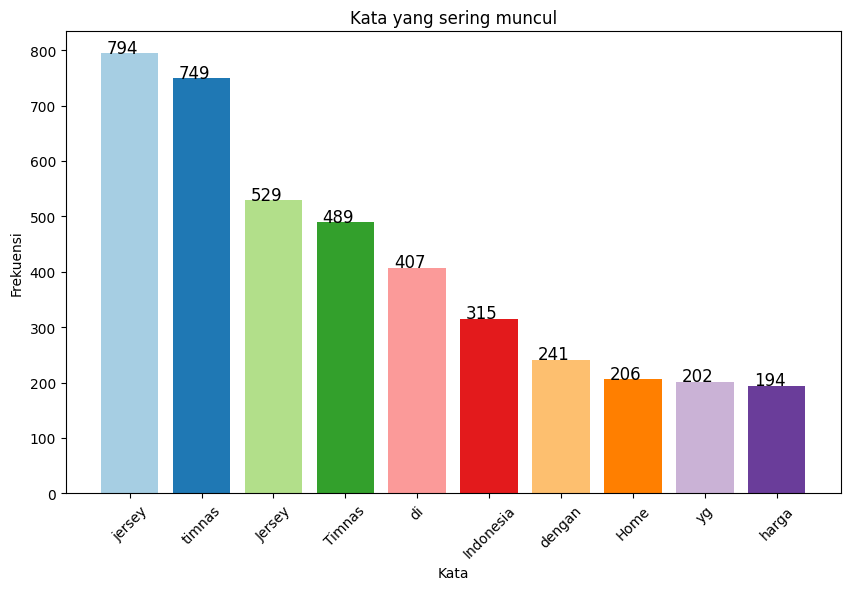

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

text = " ".join(data["full_text"])

tokens = text.split()
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)
word, count = zip(*top_words)

colors = plt.cm.Paired(range(len(word)))

plt.figure(figsize=(10, 6))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata")
plt.ylabel("Frekuensi")
plt.title("Kata yang sering muncul")
plt.xticks(rotation=45)

for bar, num in zip(bars, count):
  plt.text (bar.get_x() + bar.get_width() / 2 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')
plt.show()

# **DATA PREPROCESSING**

In [ ]:
import pandas as pd
import numpy as np

data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Kecerdasan Buatan/TUBES/jersey-erspo-1230.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1229 entries, 0 to 1228
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   conversation_id_str      1229 non-null   float64
 1   created_at               1229 non-null   object 
 2   favorite_count           1229 non-null   int64  
 3   full_text                1229 non-null   object 
 4   id_str                   1229 non-null   float64
 5   image_url                455 non-null    object 
 6   in_reply_to_screen_name  450 non-null    object 
 7   lang                     1229 non-null   object 
 8   location                 669 non-null    object 
 9   quote_count              1229 non-null   int64  
 10  reply_count              1229 non-null   int64  
 11  retweet_count            1229 non-null   int64  
 12  tweet_url                1229 non-null   object 
 13  user_id_str              1229 non-null   float64
 14  username                

In [ ]:
data.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1.793900e+18,Fri May 24 06:54:07 +0000 2024,2,Pertama kali beli jersey pabrikan Errea yang n...,1.793900e+18,NaN,NaN,art,Indonesia,0,0,0,https://x.com/Officialkjti/status/179389825277...,1.028640e+18,Officialkjti
1,1.793900e+18,Fri May 24 06:42:16 +0000 2024,4,Pertama kali beli jersey pabrikan Errea yang n...,1.793900e+18,https://pbs.twimg.com/media/GOUyO0BWwAEVvWB.jpg,NaN,in,"Sakarya, Türkiye",1,3,1,https://x.com/avicenna_ryu/status/179389527150...,9.458320e+17,avicenna_ryu
2,1.793890e+18,Fri May 24 06:39:05 +0000 2024,5,Tidak di 3 ini sih kabarnya kan cuma kabar tun...,1.793890e+18,NaN,NaN,in,Indonesia,1,3,0,https://x.com/Officialkjti/status/179389447130...,1.028640e+18,Officialkjti
3,1.793890e+18,Fri May 24 06:33:14 +0000 2024,9,Tapi isunya persib psis trus ada beberapa lagi...,1.793890e+18,NaN,NaN,in,Indonesia,2,4,2,https://x.com/Officialkjti/status/179389300000...,1.028640e+18,Officialkjti
4,1.793890e+18,Fri May 24 06:28:05 +0000 2024,1,Full interview Nunez dengan Por la Jersey: Aku...,1.793890e+18,https://pbs.twimg.com/ext_tw_video_thumb/17933...,NaN,in,Indonesia,0,0,0,https://x.com/minfieldstore/status/17938917023...,2.540793e+09,minfieldstore


In [ ]:
df = pd.DataFrame(data[['created_at', 'username', 'full_text' ]])
df.head(1229)

,created_at,username,full_text
0,Fri May 24 06:54:07 +0000 2024,Officialkjti,Pertama kali beli jersey pabrikan Errea yang n...
1,Fri May 24 06:42:16 +0000 2024,avicenna_ryu,Pertama kali beli jersey pabrikan Errea yang n...
2,Fri May 24 06:39:05 +0000 2024,Officialkjti,Tidak di 3 ini sih kabarnya kan cuma kabar tun...
3,Fri May 24 06:33:14 +0000 2024,Officialkjti,Tapi isunya persib psis trus ada beberapa lagi...
4,Fri May 24 06:28:05 +0000 2024,minfieldstore,Full interview Nunez dengan Por la Jersey: Aku...
...,...,...,...
1224,Mon Apr 29 06:52:52 +0000 2024,fazerdewz,Seumur hidup ga pernah punya jersey timnas bol...
1225,Mon Apr 29 06:43:16 +0000 2024,dennis_pw,@MafiaWasit Info sewa jersey timnas buat nobar...
1226,Mon Apr 29 06:27:24 +0000 2024,lutfielmondo,adakah yang punya info beli jersey timnas ersp...
1227,Mon Apr 29 06:19:24 +0000 2024,photostrlip,want to buy / wtb / dicari jersey timnas 2022 ...


In [ ]:

# Save the DataFrame to CSV
data.to_csv('/content/drive/MyDrive/Colab Notebooks/Kecerdasan Buatan/TUBES/jerseyindo-1230.csv', index=False)


## **CLEANING**

In [ ]:
# data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Kecerdasan Buatan/TUBES/jerseyindo-1230.csv')
# data.head(518)

df = pd.DataFrame(data[['created_at', 'username', 'full_text' ]])
df.head(1229)

,created_at,username,full_text
0,Fri May 24 06:54:07 +0000 2024,Officialkjti,Pertama kali beli jersey pabrikan Errea yang n...
1,Fri May 24 06:42:16 +0000 2024,avicenna_ryu,Pertama kali beli jersey pabrikan Errea yang n...
2,Fri May 24 06:39:05 +0000 2024,Officialkjti,Tidak di 3 ini sih kabarnya kan cuma kabar tun...
3,Fri May 24 06:33:14 +0000 2024,Officialkjti,Tapi isunya persib psis trus ada beberapa lagi...
4,Fri May 24 06:28:05 +0000 2024,minfieldstore,Full interview Nunez dengan Por la Jersey: Aku...
...,...,...,...
1224,Mon Apr 29 06:52:52 +0000 2024,fazerdewz,Seumur hidup ga pernah punya jersey timnas bol...
1225,Mon Apr 29 06:43:16 +0000 2024,dennis_pw,@MafiaWasit Info sewa jersey timnas buat nobar...
1226,Mon Apr 29 06:27:24 +0000 2024,lutfielmondo,adakah yang punya info beli jersey timnas ersp...
1227,Mon Apr 29 06:19:24 +0000 2024,photostrlip,want to buy / wtb / dicari jersey timnas 2022 ...


In [ ]:
data.drop_duplicates(subset ="full_text", keep = 'first', inplace = True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1224 entries, 0 to 1228
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   conversation_id_str      1224 non-null   float64
 1   created_at               1224 non-null   object 
 2   favorite_count           1224 non-null   int64  
 3   full_text                1224 non-null   object 
 4   id_str                   1224 non-null   float64
 5   image_url                454 non-null    object 
 6   in_reply_to_screen_name  447 non-null    object 
 7   lang                     1224 non-null   object 
 8   location                 665 non-null    object 
 9   quote_count              1224 non-null   int64  
 10  reply_count              1224 non-null   int64  
 11  retweet_count            1224 non-null   int64  
 12  tweet_url                1224 non-null   object 
 13  user_id_str              1224 non-null   float64
 14  username                 1224

In [ ]:
df = pd.DataFrame(data[['created_at', 'username', 'full_text']])
df.head()

,created_at,username,full_text
0,Fri May 24 06:54:07 +0000 2024,Officialkjti,Pertama kali beli jersey pabrikan Errea yang n...
2,Fri May 24 06:39:05 +0000 2024,Officialkjti,Tidak di 3 ini sih kabarnya kan cuma kabar tun...
3,Fri May 24 06:33:14 +0000 2024,Officialkjti,Tapi isunya persib psis trus ada beberapa lagi...
4,Fri May 24 06:28:05 +0000 2024,minfieldstore,Full interview Nunez dengan Por la Jersey: Aku...
5,Fri May 24 05:45:31 +0000 2024,amrll_is,Buat yang mau Jersey Timnas Supporter Version ...


In [ ]:
import re
import string
import nltk

#hapus url
def remove_URL(tweet):
  url = re.compile(r'https?://\S+|www\.\S+')
  return url.sub(r'', tweet)

#hapus tag html
def remove_html(tweet):
  html = re.compile(r'<.*?>')
  return html.sub(r'', tweet)

#hapus emoji
def remove_emoji(tweet):
  emoji_pattern = re.compile("["
      u"\U0001F600-\U0001F64F"
      u"\U0001F300-\U0001F5FF"
      u"\U0001F680-\U0001F6FF"
      u"\U0001F1E0-\U0001F1FF"
                          "]+", flags=re.UNICODE)
  return emoji_pattern.sub(r'', tweet)

#hapus angka
def remove_numbers(tweet):
  tweet = re.sub(r'\d+', '', tweet)
  return tweet

#hapus tanda baca
def remove_puncts(tweets):
  transalator = str.maketrans('', '', string.punctuation)
  return tweets.translate(transalator)



df['cleansing'] = df['full_text'].apply(lambda x: remove_URL(x))
df['cleansing'] = df['cleansing'].apply(lambda x: remove_html(x))
df['cleansing'] = df['cleansing'].apply(lambda x: remove_emoji(x))
df['cleansing'] = df['cleansing'].apply(lambda x: remove_puncts(x))
df['cleansing'] = df['cleansing'].apply(lambda x: remove_numbers(x))

# pd.set_option('display.max_colwidth', None)

# df.head(515)
df[['full_text', 'cleansing']].head(1229)



,full_text,cleansing
0,Pertama kali beli jersey pabrikan Errea yang n...,Pertama kali beli jersey pabrikan Errea yang n...
2,Tidak di 3 ini sih kabarnya kan cuma kabar tun...,Tidak di ini sih kabarnya kan cuma kabar tung...
3,Tapi isunya persib psis trus ada beberapa lagi...,Tapi isunya persib psis trus ada beberapa lagi...
4,Full interview Nunez dengan Por la Jersey: Aku...,Full interview Nunez dengan Por la Jersey Aku ...
5,Buat yang mau Jersey Timnas Supporter Version ...,Buat yang mau Jersey Timnas Supporter Version ...
...,...,...
1224,Seumur hidup ga pernah punya jersey timnas bol...,Seumur hidup ga pernah punya jersey timnas bol...
1225,@MafiaWasit Info sewa jersey timnas buat nobar...,MafiaWasit Info sewa jersey timnas buat nobar ...
1226,adakah yang punya info beli jersey timnas ersp...,adakah yang punya info beli jersey timnas ersp...
1227,want to buy / wtb / dicari jersey timnas 2022 ...,want to buy wtb dicari jersey timnas home p...


## **CASE FOLDING**

Case folding dipake buat merubah dari huruf besar ke huruf kecil semua

In [ ]:
# Definisikan fungsi case_folding untuk mengubah semua huruf dalam teks menjadi huruf kecil
def case_folding(text):
    # Periksa apakah input 'text' adalah string
    if isinstance(text, str):
        # Ubah semua karakter dalam 'text' menjadi huruf kecil
        lowercase_text = text.lower()
        # Kembalikan teks yang sudah diubah menjadi huruf kecil
        return lowercase_text
    else:
        # Jika input bukan string, kembalikan input tanpa perubahan
        return text

# Terapkan fungsi case_folding pada setiap elemen di kolom 'cleasing' dari DataFrame 'df'
# Hasilnya disimpan ke kolom baru bernama 'case_folding'
df['case_folding'] = df['cleansing'].apply(case_folding)
# df.head(515)

df[['full_text','case_folding']].head(1229)

,full_text,case_folding
0,Pertama kali beli jersey pabrikan Errea yang n...,pertama kali beli jersey pabrikan errea yang n...
2,Tidak di 3 ini sih kabarnya kan cuma kabar tun...,tidak di ini sih kabarnya kan cuma kabar tung...
3,Tapi isunya persib psis trus ada beberapa lagi...,tapi isunya persib psis trus ada beberapa lagi...
4,Full interview Nunez dengan Por la Jersey: Aku...,full interview nunez dengan por la jersey aku ...
5,Buat yang mau Jersey Timnas Supporter Version ...,buat yang mau jersey timnas supporter version ...
...,...,...
1224,Seumur hidup ga pernah punya jersey timnas bol...,seumur hidup ga pernah punya jersey timnas bol...
1225,@MafiaWasit Info sewa jersey timnas buat nobar...,mafiawasit info sewa jersey timnas buat nobar ...
1226,adakah yang punya info beli jersey timnas ersp...,adakah yang punya info beli jersey timnas ersp...
1227,want to buy / wtb / dicari jersey timnas 2022 ...,want to buy wtb dicari jersey timnas home p...


## **TOKENIZATION**

Tokenisasi adalah cara untuk membagi teks atau dokumen menjadi bagian-bagian yang lebih kecil yang disebut token

In [ ]:
# Mendefinisikan fungsi tokenize untuk membagi teks menjadi token-token individu
def tokenize(text):
    # Memecah teks menjadi token-token menggunakan spasi sebagai pemisah
    tokens = text.split()
    # Mengembalikan daftar token yang dihasilkan
    return tokens

# Menggunakan fungsi tokenize pada setiap elemen di kolom 'case_folding' dari DataFrame 'df'
# Hasilnya disimpan ke dalam kolom baru bernama 'tokenize'
df['tokenize'] = df['case_folding'].apply(tokenize)
# df.head(515)

df[['full_text','tokenize']].head(1229)

,full_text,tokenize
0,Pertama kali beli jersey pabrikan Errea yang n...,"[pertama, kali, beli, jersey, pabrikan, errea,..."
2,Tidak di 3 ini sih kabarnya kan cuma kabar tun...,"[tidak, di, ini, sih, kabarnya, kan, cuma, kab..."
3,Tapi isunya persib psis trus ada beberapa lagi...,"[tapi, isunya, persib, psis, trus, ada, bebera..."
4,Full interview Nunez dengan Por la Jersey: Aku...,"[full, interview, nunez, dengan, por, la, jers..."
5,Buat yang mau Jersey Timnas Supporter Version ...,"[buat, yang, mau, jersey, timnas, supporter, v..."
...,...,...
1224,Seumur hidup ga pernah punya jersey timnas bol...,"[seumur, hidup, ga, pernah, punya, jersey, tim..."
1225,@MafiaWasit Info sewa jersey timnas buat nobar...,"[mafiawasit, info, sewa, jersey, timnas, buat,..."
1226,adakah yang punya info beli jersey timnas ersp...,"[adakah, yang, punya, info, beli, jersey, timn..."
1227,want to buy / wtb / dicari jersey timnas 2022 ...,"[want, to, buy, wtb, dicari, jersey, timnas, h..."


## **FILTERING/STOPWORD REMOVAL**

Proses menghapus kata-kata yang umum atau kurang bermakna dari teks.

In [ ]:
# Mengimpor modul 'stopwords' dari corpus NLTK (Natural Language Toolkit)
from nltk.corpus import stopwords

# Mengunduh kamus stopwords bahasa Indonesia dari NLTK jika belum tersedia
nltk.download('stopwords')

# Mendapatkan daftar stopwords bahasa Indonesia dari modul 'stopwords' NLTK
stop_words = stopwords.words('indonesian')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Mendefinisikan fungsi untuk menghapus stopwords dari teks
def remove_stopwords(text):
    # Menggunakan list comprehension untuk membuat daftar kata-kata yang bukan stopwords
    return [word for word in text if word not in stop_words]

# Menggunakan fungsi remove_stopwords pada setiap elemen di kolom 'tokenize' dari DataFrame 'df'
# Hasilnya disimpan ke dalam kolom baru bernama 'Filtering/stopword removal'
df['Filtering/stopword removal'] = df['tokenize'].apply(lambda x: remove_stopwords(x))

# df.head(515)

df[['full_text', 'Filtering/stopword removal']].head(1229)


,full_text,Filtering/stopword removal
0,Pertama kali beli jersey pabrikan Errea yang n...,"[kali, beli, jersey, pabrikan, errea, ngegarap..."
2,Tidak di 3 ini sih kabarnya kan cuma kabar tun...,"[sih, kabarnya, kabar, tunggu, aja, juli, kaya..."
3,Tapi isunya persib psis trus ada beberapa lagi...,"[isunya, persib, psis, trus, pakai, apparel, m..."
4,Full interview Nunez dengan Por la Jersey: Aku...,"[full, interview, nunez, por, la, jersey, ruma..."
5,Buat yang mau Jersey Timnas Supporter Version ...,"[jersey, timnas, supporter, version, ori, home..."
...,...,...
1224,Seumur hidup ga pernah punya jersey timnas bol...,"[seumur, hidup, ga, jersey, timnas, bola, indo..."
1225,@MafiaWasit Info sewa jersey timnas buat nobar...,"[mafiawasit, info, sewa, jersey, timnas, nobar..."
1226,adakah yang punya info beli jersey timnas ersp...,"[adakah, info, beli, jersey, timnas, erspo, di..."
1227,want to buy / wtb / dicari jersey timnas 2022 ...,"[want, to, buy, wtb, dicari, jersey, timnas, h..."


## **STEAMING DATA**

Proses mengubah kata-kata menjadi bentuk dasarnya atau kata dasar.

In [ ]:
# Menginstal library Sastrawi untuk pemrosesan bahasa Indonesia
!pip install Sastrawi

# Mengimpor kelas StemmerFactory dari modul Sastrawi untuk membuat objek stemmer Bahasa Indonesia
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
# Mengimpor kelas PorterStemmer dari modul nltk.stem untuk membuat objek stemmer Porter
from nltk.stem import PorterStemmer
# Mengimpor kelas SnowballStemmer dari modul nltk.stem.snowball untuk membuat objek stemmer Snowball
from nltk.stem.snowball import SnowballStemmer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.8 MB/s eta 0:00:00


In [ ]:
# Membuat objek factory StemmerFactory
factory = StemmerFactory()

# Membuat objek stemmer menggunakan StemmerFactory
stemmer = factory.create_stemmer()

# Mendefinisikan fungsi untuk melakukan stemming pada teks
def stem_text(text):
    # Menggunakan stemmer untuk melakukan stemming pada setiap kata dalam teks
    return [stemmer.stem(word) for word in text]

# Menggunakan fungsi stem_text pada setiap elemen di kolom 'Filtering/stopword removal' dari DataFrame 'df'
# Hasilnya digabungkan kembali menjadi string dan disimpan dalam kolom baru 'stemming_data'
df['stemming_data'] = df['Filtering/stopword removal'].apply(lambda x: ' '.join(stem_text(x)))

# df.head(416)

df[['full_text','stemming_data']].head(1229)


,full_text,stemming_data
0,Pertama kali beli jersey pabrikan Errea yang n...,kali beli jersey pabrikan errea ngegarap jerse...
2,Tidak di 3 ini sih kabarnya kan cuma kabar tun...,sih kabar kabar tunggu aja juli kaya udah dium...
3,Tapi isunya persib psis trus ada beberapa lagi...,isu persib psis trus pakai apparel musim
4,Full interview Nunez dengan Por la Jersey: Aku...,full interview nunez por la jersey rumah timna...
5,Buat yang mau Jersey Timnas Supporter Version ...,jersey timnas supporter version ori home away ...
...,...,...
1224,Seumur hidup ga pernah punya jersey timnas bol...,umur hidup ga jersey timnas bola indonesia kal...
1225,@MafiaWasit Info sewa jersey timnas buat nobar...,mafiawasit info sewa jersey timnas nobar malam...
1226,adakah yang punya info beli jersey timnas ersp...,ada info beli jersey timnas erspo mana
1227,want to buy / wtb / dicari jersey timnas 2022 ...,want to buy wtb cari jersey timnas home player...


## **NORMALISASI**

Proses membuat atau mengubah teks menjadi bentuk standar atau normal

In [ ]:
# Mendefinisikan fungsi untuk normalisasi teks
def text_normalization(text):
    # Mengembalikan teks tanpa perubahan
    normalized_text = text
    return normalized_text

# Menggunakan fungsi text_normalization pada setiap elemen di kolom 'stemming_data' dari DataFrame 'df'
# Hasilnya disimpan dalam kolom baru 'normalized_text'
df['normalized_text'] = df['stemming_data'].apply(text_normalization)
# df.head(416)

df[['full_text', 'normalized_text']].head(1229)

,full_text,normalized_text
0,Pertama kali beli jersey pabrikan Errea yang n...,kali beli jersey pabrikan errea ngegarap jerse...
2,Tidak di 3 ini sih kabarnya kan cuma kabar tun...,sih kabar kabar tunggu aja juli kaya udah dium...
3,Tapi isunya persib psis trus ada beberapa lagi...,isu persib psis trus pakai apparel musim
4,Full interview Nunez dengan Por la Jersey: Aku...,full interview nunez por la jersey rumah timna...
5,Buat yang mau Jersey Timnas Supporter Version ...,jersey timnas supporter version ori home away ...
...,...,...
1224,Seumur hidup ga pernah punya jersey timnas bol...,umur hidup ga jersey timnas bola indonesia kal...
1225,@MafiaWasit Info sewa jersey timnas buat nobar...,mafiawasit info sewa jersey timnas nobar malam...
1226,adakah yang punya info beli jersey timnas ersp...,ada info beli jersey timnas erspo mana
1227,want to buy / wtb / dicari jersey timnas 2022 ...,want to buy wtb cari jersey timnas home player...


## **Download Data Hasil Pre-Processing**

In [ ]:
# Menyimpan DataFrame ke dalam file CSV dengan nama 'hasil-preprocessing-data-jerseyindo-3-juni.csv'
# Encoding 'utf8' digunakan untuk memastikan kompatibilitas karakter unicode
# Parameter 'index=False' digunakan untuk mengabaikan penambahan indeks baris dalam file CSV

df.to_csv('preprocessing-14-juni.csv', encoding='utf8', index=False)

# **VISUALISASI DATA SETELAH PRE-PROCESSING**

In [ ]:
# Mengimpor kelas WordCloud dari modul wordcloud untuk membuat word cloud
from wordcloud import WordCloud

# Mengimpor modul pyplot dari matplotlib untuk plotting
import matplotlib.pyplot as pkt

# Mengimpor modul pandas untuk manipulasi dan analisis data
import pandas

# Membaca file CSV yang berisi data yang sudah diproses sebelumnya
# DataFrame hasil pembacaan disimpan dalam variabel 'df'
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Kecerdasan Buatan/TUBES/preprocessing-14-juni.csv')

In [ ]:
df.head()

,created_at,username,full_text,cleasing,case_folding,tokenize,Filtering/stopword removal,stemming_data,normalized_text
0,Fri May 24 06:54:07 +0000 2024,Officialkjti,Pertama kali beli jersey pabrikan Errea yang n...,Pertama kali beli jersey pabrikan Errea yang n...,pertama kali beli jersey pabrikan errea yang n...,"['pertama', 'kali', 'beli', 'jersey', 'pabrika...","['kali', 'beli', 'jersey', 'pabrikan', 'errea'...",kali beli jersey pabrikan errea ngegarap jerse...,kali beli jersey pabrikan errea ngegarap jerse...
1,Fri May 24 06:39:05 +0000 2024,Officialkjti,Tidak di 3 ini sih kabarnya kan cuma kabar tun...,Tidak di ini sih kabarnya kan cuma kabar tung...,tidak di ini sih kabarnya kan cuma kabar tung...,"['tidak', 'di', 'ini', 'sih', 'kabarnya', 'kan...","['sih', 'kabarnya', 'kabar', 'tunggu', 'aja', ...",sih kabar kabar tunggu aja juli kaya udah dium...,sih kabar kabar tunggu aja juli kaya udah dium...
2,Fri May 24 06:33:14 +0000 2024,Officialkjti,Tapi isunya persib psis trus ada beberapa lagi...,Tapi isunya persib psis trus ada beberapa lagi...,tapi isunya persib psis trus ada beberapa lagi...,"['tapi', 'isunya', 'persib', 'psis', 'trus', '...","['isunya', 'persib', 'psis', 'trus', 'pakai', ...",isu persib psis trus pakai apparel musim,isu persib psis trus pakai apparel musim
3,Fri May 24 06:28:05 +0000 2024,minfieldstore,Full interview Nunez dengan Por la Jersey: Aku...,Full interview Nunez dengan Por la Jersey Aku ...,full interview nunez dengan por la jersey aku ...,"['full', 'interview', 'nunez', 'dengan', 'por'...","['full', 'interview', 'nunez', 'por', 'la', 'j...",full interview nunez por la jersey rumah timna...,full interview nunez por la jersey rumah timna...
4,Fri May 24 05:45:31 +0000 2024,amrll_is,Buat yang mau Jersey Timnas Supporter Version ...,Buat yang mau Jersey Timnas Supporter Version ...,buat yang mau jersey timnas supporter version ...,"['buat', 'yang', 'mau', 'jersey', 'timnas', 's...","['jersey', 'timnas', 'supporter', 'version', '...",jersey timnas supporter version ori home away ...,jersey timnas supporter version ori home away ...


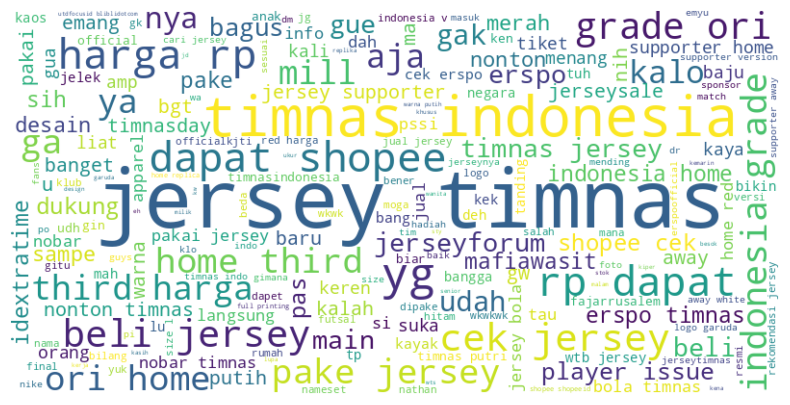

In [ ]:
# Memastikan semua elemen dalam kolom 'normalized_text' adalah string
# Jika elemen bukan string, akan diubah menjadi string kosong
df['normalized_text'] = df['normalized_text'].apply(lambda x: str(x) if isinstance(x, (str, int, float)) else '')

# Menggabungkan semua string menjadi satu string tunggal
text = ' '.join(df['normalized_text'])

# Menghasilkan word cloudcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Membuat objek WordCloud dengan parameter lebar=800, tinggi=400, dan warna latar belakang hitam
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Menampilkan word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


In [ ]:
# Mengimpor modul matplotlib.pyplot sebagai plt untuk plotting
import matplotlib.pyplot as plt

# Mengimpor kelas Counter dari modul collections untuk menghitung frekuensi kemunculan kata-kata
from collections import Counter

# Menggabungkan semua teks dari kolom 'normalized_text' menjadi satu string
text = " ".join(df['normalized_text'].apply(lambda x: str(x) if isinstance(x, (str, int, float)) else ''))

# Memisahkan string teks menjadi token (kata-kata)
tokens = text.split()

# Menghitung frekuensi kemunculan setiap kata
word_counts = Counter(tokens)

# Mengambil 10 kata yang paling sering muncul beserta frekuensinya
top_words = word_counts.most_common(10)
word, count = zip(*top_words)

# Menentukan warna untuk setiap bar berdasarkan indeks kata
colors = plt.cm.Paired(range(len(word)))

# Membuat plot bar
plt.figure(figsize=(10, 6))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata")
plt.ylabel("Frekuensi")
plt.title("Kata yang sering muncul")
plt.xticks(rotation=45)

# Menambahkan label untuk setiap bar yang menampilkan frekuensi
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')

# Menampilkan plot
plt.show()


NameError: name 'df' is not defined

# **LABELING**

## **PAKE NLTK**

In [ ]:
# Mengimpor modul pandas sebagai pd untuk manipulasi data
import pandas as pd
# Mengimpor modul numpy sebagai np untuk manipulasi array dan data numerik
import numpy as np

# Mendefinisikan fungsi load_data() untuk memuat data dari file CSV
def load_data():
    # Membaca data dari file CSV yang disimpan di lokasi tertentu
    data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Kecerdasan Buatan/TUBES/preprocessing-14-juni.csv')
    # Mengembalikan DataFrame yang berisi data yang dimuat
    return data

# Memuat data dengan memanggil fungsi load_data() dan menyimpannya dalam variabel 'data'
data = load_data()

# Menampilkan 1000 baris pertama dari DataFrame 'data' untuk memeriksa data yang dimuat
data.head(1000)


,created_at,username,full_text,cleasing,case_folding,tokenize,Filtering/stopword removal,stemming_data,normalized_text
0,Fri May 24 06:54:07 +0000 2024,Officialkjti,Pertama kali beli jersey pabrikan Errea yang n...,Pertama kali beli jersey pabrikan Errea yang n...,pertama kali beli jersey pabrikan errea yang n...,"['pertama', 'kali', 'beli', 'jersey', 'pabrika...","['kali', 'beli', 'jersey', 'pabrikan', 'errea'...",kali beli jersey pabrikan errea ngegarap jerse...,kali beli jersey pabrikan errea ngegarap jerse...
1,Fri May 24 06:39:05 +0000 2024,Officialkjti,Tidak di 3 ini sih kabarnya kan cuma kabar tun...,Tidak di ini sih kabarnya kan cuma kabar tung...,tidak di ini sih kabarnya kan cuma kabar tung...,"['tidak', 'di', 'ini', 'sih', 'kabarnya', 'kan...","['sih', 'kabarnya', 'kabar', 'tunggu', 'aja', ...",sih kabar kabar tunggu aja juli kaya udah dium...,sih kabar kabar tunggu aja juli kaya udah dium...
2,Fri May 24 06:33:14 +0000 2024,Officialkjti,Tapi isunya persib psis trus ada beberapa lagi...,Tapi isunya persib psis trus ada beberapa lagi...,tapi isunya persib psis trus ada beberapa lagi...,"['tapi', 'isunya', 'persib', 'psis', 'trus', '...","['isunya', 'persib', 'psis', 'trus', 'pakai', ...",isu persib psis trus pakai apparel musim,isu persib psis trus pakai apparel musim
3,Fri May 24 06:28:05 +0000 2024,minfieldstore,Full interview Nunez dengan Por la Jersey: Aku...,Full interview Nunez dengan Por la Jersey Aku ...,full interview nunez dengan por la jersey aku ...,"['full', 'interview', 'nunez', 'dengan', 'por'...","['full', 'interview', 'nunez', 'por', 'la', 'j...",full interview nunez por la jersey rumah timna...,full interview nunez por la jersey rumah timna...
4,Fri May 24 05:45:31 +0000 2024,amrll_is,Buat yang mau Jersey Timnas Supporter Version ...,Buat yang mau Jersey Timnas Supporter Version ...,buat yang mau jersey timnas supporter version ...,"['buat', 'yang', 'mau', 'jersey', 'timnas', 's...","['jersey', 'timnas', 'supporter', 'version', '...",jersey timnas supporter version ori home away ...,jersey timnas supporter version ori home away ...
...,...,...,...,...,...,...,...,...,...
995,Wed May 01 10:18:40 +0000 2024,ahmdluck,Cocok Buat kamu yang lagi cari jersey timnas d...,Cocok Buat kamu yang lagi cari jersey timnas d...,cocok buat kamu yang lagi cari jersey timnas d...,"['cocok', 'buat', 'kamu', 'yang', 'lagi', 'car...","['cocok', 'cari', 'jersey', 'timnas', 'erspo',...",cocok cari jersey timnas erspo supporter home ...,cocok cari jersey timnas erspo supporter home ...
996,Wed May 01 10:04:27 +0000 2024,WKristiant,Cek Jersey Timnas Indonesia 2023 Grade Ori Hom...,Cek Jersey Timnas Indonesia Grade Ori Home Th...,cek jersey timnas indonesia grade ori home th...,"['cek', 'jersey', 'timnas', 'indonesia', 'grad...","['cek', 'jersey', 'timnas', 'indonesia', 'grad...",cek jersey timnas indonesia grade ori home thi...,cek jersey timnas indonesia grade ori home thi...
997,Wed May 01 09:49:37 +0000 2024,satyaadiw,Liat di pintu toko olahraga tertempel kertas b...,Liat di pintu toko olahraga tertempel kertas b...,liat di pintu toko olahraga tertempel kertas b...,"['liat', 'di', 'pintu', 'toko', 'olahraga', 't...","['liat', 'pintu', 'toko', 'olahraga', 'tertemp...",liat pintu toko olahraga tempel kertas tulis j...,liat pintu toko olahraga tempel kertas tulis j...
998,Wed May 01 09:33:35 +0000 2024,struick_is_cool,@only_cool_vibes Boleh dipilih pake dua jersey...,onlycoolvibes Boleh dipilih pake dua jersey be...,onlycoolvibes boleh dipilih pake dua jersey be...,"['onlycoolvibes', 'boleh', 'dipilih', 'pake', ...","['onlycoolvibes', 'dipilih', 'pake', 'jersey',...",onlycoolvibes pilih pake jersey beda jersey ti...,onlycoolvibes pilih pake jersey beda jersey ti...


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1224 entries, 0 to 1223
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   created_at                  1224 non-null   object
 1   username                    1224 non-null   object
 2   full_text                   1224 non-null   object
 3   cleasing                    1224 non-null   object
 4   case_folding                1224 non-null   object
 5   tokenize                    1224 non-null   object
 6   Filtering/stopword removal  1224 non-null   object
 7   stemming_data               1223 non-null   object
 8   normalized_text             1223 non-null   object
dtypes: object(9)
memory usage: 86.2+ KB


In [ ]:
# Membuat DataFrame baru dengan nama 'df' yang berisi kolom 'stemming_data' dari DataFrame 'data'
df = pd.DataFrame(data['stemming_data'])

# Menampilkan 5 baris pertama dari DataFrame 'df' untuk memeriksa data
df.head(5)


,stemming_data
0,kali beli jersey pabrikan errea ngegarap jerse...
1,sih kabar kabar tunggu aja juli kaya udah dium...
2,isu persib psis trus pakai apparel musim
3,full interview nunez por la jersey rumah timna...
4,jersey timnas supporter version ori home away ...


In [ ]:
# Menginstal NLTK (Natural Language Toolkit) menggunakan pip
!pip install nltk

# Mengimpor modul nltk untuk pemrosesan bahasa alami
import nltk
# Mengimpor kelas SentimentIntensityAnalyzer dari modul sentiment di NLTK
from nltk.sentiment import SentimentIntensityAnalyzer
# Mengimpor modul pandas sebagai pd untuk manipulasi data
import pandas as pd

# Mengunduh data yang diperlukan untuk tokenisasi menggunakan fungsi download dari NLTK
nltk.download('punkt')
# Mengunduh kamus Vader Lexicon untuk analisis sentimen menggunakan fungsi download dari NLTK
nltk.download('vader_lexicon')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
# Inisialisasi SentimentIntensityAnalyzer dari modul nltk.sentiment
data = SentimentIntensityAnalyzer()

# Inisialisasi daftar untuk menyimpan label sentimen dan skor sentimen
labels = []
scores = []

# Iterasi melalui setiap teks dalam kolom 'stemming_data'
for text in df['stemming_data']:
    # Menghitung skor sentimen menggunakan SentimentIntensityAnalyzer
    sentiment_scores = data.polarity_scores(text)
    # Mengambil skor komposit dari hasil sentimen
    compound_score = sentiment_scores['compound']

    # Menambahkan skor sentimen ke dalam daftar
    scores.append(compound_score)

    # Menentukan label sentimen berdasarkan skor komposit
    if compound_score > 0:
        label = 'positif'
    elif compound_score < 0:
        label = 'negatif'
    else:
        label = 'netral'

    # Menambahkan label sentimen ke dalam daftar
    labels.append(label)

# Menambahkan kolom sentimen_score dan sentiment ke dalam DataFrame 'df'
df['sentiment_score'] = scores
df['sentiment'] = labels

# Memilih kolom 'stemming_data', 'sentiment_score', dan 'sentiment' dari DataFrame dan menyimpannya dalam variabel 'data'
data = df[['stemming_data', 'sentiment_score', 'sentiment']]

# Menampilkan 5 baris pertama dari DataFrame 'data'
data.head(5)


,stemming_data,sentiment_score,sentiment
0,kali beli jersey pabrikan errea ngegarap jerse...,0.0000,netral
1,sih kabar kabar tunggu aja juli kaya udah dium...,0.0000,netral
2,isu persib psis trus pakai apparel musim,0.0000,netral
3,full interview nunez por la jersey rumah timna...,0.0000,netral
4,jersey timnas supporter version ori home away ...,-0.3612,negatif


<ipython-input-88-e0c00d0ecd4b>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')


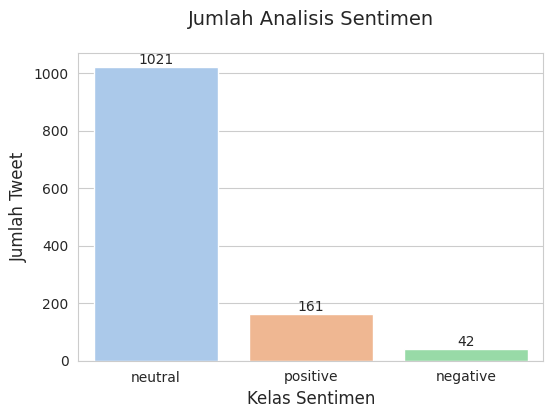

In [ ]:
# Mengonversi semua entri ke string dan mengganti nilai NaN dengan string kosong
df['stemming_data'] = df['stemming_data'].astype(str).fillna('')

# Menginisialisasi analisis sentimen VADER
sid = SentimentIntensityAnalyzer()

# Menghitung skor sentimen
df['sentiment_scores'] = df['stemming_data'].apply(lambda text: sid.polarity_scores(text))

# Mengekstrak skor compound dan mengklasifikasikan sentimen berdasarkan itu
df['sentiment'] = df['sentiment_scores'].apply(lambda score_dict: score_dict['compound'])
df['sentiment_class'] = df['sentiment'].apply(lambda score: 'positive' if score >= 0.05 else ('negative' if score <= -0.05 else 'neutral'))

# Menghitung jumlah setiap kelas sentimen
sentiment_count = df['sentiment_class'].value_counts()

# Plotting
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')
plt.title('Jumlah Analisis Sentimen', fontsize=14, pad=20)
plt.xlabel('Kelas Sentimen', fontsize=12)
plt.ylabel('Jumlah Tweet', fontsize=12)

# Memberi anotasi pada plot batang
for i, count in enumerate(sentiment_count.values):
    ax.text(i, count + 0.10, str(count), ha='center', va='bottom')

plt.show()


<ipython-input-87-a5b59863bc8f>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')


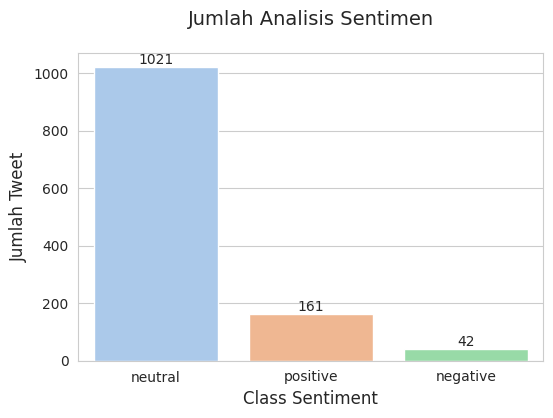

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Assuming 'data' is your dataframe and 'stemming_data' is the column to analyze

# Ensure data is correctly assigned as a dataframe
# Convert all entries to strings and replace NaN values with empty string
df['stemming_data'] = df['stemming_data'].astype(str).fillna('')

# Initialize VADER sentiment analyzer
sid = SentimentIntensityAnalyzer()

# Compute sentiment scores
df['sentiment_scores'] = df['stemming_data'].apply(lambda text: sid.polarity_scores(text))

# Extract compound score and classify sentiment based on it
df['sentiment'] = df['sentiment_scores'].apply(lambda score_dict: score_dict['compound'])
df['sentiment_class'] = df['sentiment'].apply(lambda score: 'positive' if score >= 0.05 else ('negative' if score <= -0.05 else 'neutral'))

# Count the number of each sentiment class
sentiment_count = df['sentiment_class'].value_counts()

# Plotting
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')
plt.title('Jumlah Analisis Sentimen', fontsize=14, pad=20)
plt.xlabel('Class Sentiment', fontsize=12)
plt.ylabel('Jumlah Tweet', fontsize=12)

# Annotate the bar plot
for i, count in enumerate(sentiment_count.values):
    ax.text(i, count + 0.10, str(count), ha='center', va='bottom')

plt.show()


In [ ]:
data.to_csv('Hasil-Labelling-Data-NLTK-14-juni.csv', encoding='utf8', index=False)

## **PAKE TEXTBLOB**

In [ ]:
# Mengimpor modul pandas sebagai pd untuk manipulasi data
import pandas as pd
# Mengimpor modul numpy sebagai np untuk manipulasi array dan data numerik
import numpy as np

# Mendefinisikan fungsi load_data() untuk memuat data dari file CSV
def load_data():
    # Membaca data dari file CSV yang disimpan di lokasi tertentu
    data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Kecerdasan Buatan/TUBES/preprocessing-14-juni.csv')
    # Mengembalikan DataFrame yang berisi data yang dimuat
    return data

# Memuat data dengan memanggil fungsi load_data() dan menyimpannya dalam variabel 'data'
data = load_data()

# Menampilkan 5 baris pertama dari DataFrame 'data' untuk memeriksa data yang dimuat
data.head(5)


,created_at,username,full_text,cleasing,case_folding,tokenize,Filtering/stopword removal,stemming_data,normalized_text
0,Fri May 24 06:54:07 +0000 2024,Officialkjti,Pertama kali beli jersey pabrikan Errea yang n...,Pertama kali beli jersey pabrikan Errea yang n...,pertama kali beli jersey pabrikan errea yang n...,"['pertama', 'kali', 'beli', 'jersey', 'pabrika...","['kali', 'beli', 'jersey', 'pabrikan', 'errea'...",kali beli jersey pabrikan errea ngegarap jerse...,kali beli jersey pabrikan errea ngegarap jerse...
1,Fri May 24 06:39:05 +0000 2024,Officialkjti,Tidak di 3 ini sih kabarnya kan cuma kabar tun...,Tidak di ini sih kabarnya kan cuma kabar tung...,tidak di ini sih kabarnya kan cuma kabar tung...,"['tidak', 'di', 'ini', 'sih', 'kabarnya', 'kan...","['sih', 'kabarnya', 'kabar', 'tunggu', 'aja', ...",sih kabar kabar tunggu aja juli kaya udah dium...,sih kabar kabar tunggu aja juli kaya udah dium...
2,Fri May 24 06:33:14 +0000 2024,Officialkjti,Tapi isunya persib psis trus ada beberapa lagi...,Tapi isunya persib psis trus ada beberapa lagi...,tapi isunya persib psis trus ada beberapa lagi...,"['tapi', 'isunya', 'persib', 'psis', 'trus', '...","['isunya', 'persib', 'psis', 'trus', 'pakai', ...",isu persib psis trus pakai apparel musim,isu persib psis trus pakai apparel musim
3,Fri May 24 06:28:05 +0000 2024,minfieldstore,Full interview Nunez dengan Por la Jersey: Aku...,Full interview Nunez dengan Por la Jersey Aku ...,full interview nunez dengan por la jersey aku ...,"['full', 'interview', 'nunez', 'dengan', 'por'...","['full', 'interview', 'nunez', 'por', 'la', 'j...",full interview nunez por la jersey rumah timna...,full interview nunez por la jersey rumah timna...
4,Fri May 24 05:45:31 +0000 2024,amrll_is,Buat yang mau Jersey Timnas Supporter Version ...,Buat yang mau Jersey Timnas Supporter Version ...,buat yang mau jersey timnas supporter version ...,"['buat', 'yang', 'mau', 'jersey', 'timnas', 's...","['jersey', 'timnas', 'supporter', 'version', '...",jersey timnas supporter version ori home away ...,jersey timnas supporter version ori home away ...


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1224 entries, 0 to 1223
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   created_at                  1224 non-null   object
 1   username                    1224 non-null   object
 2   full_text                   1224 non-null   object
 3   cleasing                    1224 non-null   object
 4   case_folding                1224 non-null   object
 5   tokenize                    1224 non-null   object
 6   Filtering/stopword removal  1224 non-null   object
 7   stemming_data               1223 non-null   object
 8   normalized_text             1223 non-null   object
dtypes: object(9)
memory usage: 86.2+ KB


In [ ]:
df = pd.DataFrame(data['stemming_data'])
df.head(1229)

,stemming_data
0,kali beli jersey pabrikan errea ngegarap jerse...
1,sih kabar kabar tunggu aja juli kaya udah dium...
2,isu persib psis trus pakai apparel musim
3,full interview nunez por la jersey rumah timna...
4,jersey timnas supporter version ori home away ...
...,...
1219,umur hidup ga jersey timnas bola indonesia kal...
1220,mafiawasit info sewa jersey timnas nobar malam...
1221,ada info beli jersey timnas erspo mana
1222,want to buy wtb cari jersey timnas home player...


In [ ]:
!pip install textblob

In [ ]:
# # Mengimpor kelas TextBlob dari modul textblob
# from textblob import TextBlob
# # Mengimpor modul pandas sebagai pd untuk manipulasi data
# import pandas as pd

# # Pastikan 'df' adalah DataFrame Anda dan 'stemming_data' adalah kolom yang akan dianalisis
# # Konversi semua entri menjadi string dan ganti nilai NaN dengan string kosong
# df['stemming_data'] = df['stemming_data'].astype(str).fillna('')

# # Inisialisasi daftar untuk menyimpan skor sentimen dan label sentimen
# scores = []
# labels = []

# # Iterasi melalui setiap teks dalam kolom 'stemming_data'
# for text in df['stemming_data']:
#     # Membuat objek TextBlob dari teks
#     blob = TextBlob(text)
#     # Menghitung polaritas sentimen menggunakan TextBlob
#     polarity = blob.sentiment.polarity

#     # Menentukan label sentimen berdasarkan polaritas
#     if polarity > 0:
#         label = 'positif'
#     elif polarity < 0:
#         label = 'negatif'
#     else:
#         label = 'netral'

#     # Menambahkan polaritas dan label sentimen ke dalam daftar
#     scores.append(polarity)
#     labels.append(label)

# # Menambahkan kolom sentimen dan skor sentimen ke dalam DataFrame 'df'
# df['sentiment'] = labels
# df['sentiment_score'] = scores

# # Memilih kolom 'stemming_data', 'sentiment_score', dan 'sentiment' dari DataFrame dan menyimpannya dalam variabel 'data'
# data = df[['stemming_data', 'sentiment_score', 'sentiment']]

# # Menampilkan 1224 baris pertama dari DataFrame 'data'
# print(data.head(1224))

# Mengimpor kelas TextBlob dari modul textblob
# from textblob import TextBlob

# # Inisialisasi daftar untuk menyimpan skor sentimen dan label sentimen
# scores = []
# labels = []

# # Iterasi melalui setiap teks dalam kolom 'stemming_data'
# for text in df['stemming_data']:
#     # Membuat objek TextBlob dari teks
#     blob = TextBlob(text)
#     # Menghitung polaritas sentimen menggunakan TextBlob
#     polarity = blob.sentiment.polarity

#     # Menentukan label sentimen berdasarkan polaritas
#     if polarity > 0:
#         label = 'positif'
#     elif polarity < 0:
#         label = 'negatif'
#     else:
#         label = 'netral'

#     # Menambahkan polaritas dan label sentimen ke dalam daftar
#     scores.append(polarity)
#     labels.append(label)

# # Menambahkan kolom sentimen dan skor sentimen ke dalam DataFrame 'df'
# df['sentiment'] = labels
# df['sentiment_score'] = scores

# # Memilih kolom 'stemming_data', 'sentiment_score', dan 'sentiment' dari DataFrame dan menyimpannya dalam variabel 'data'
# data = df[['stemming_data', 'sentiment_score', 'sentiment']]

# # Menampilkan 5 baris pertama dari DataFrame 'data'
# data.head(1229)


# Mengimpor kelas TextBlob dari modul textblob
from textblob import TextBlob

# Inisialisasi daftar untuk menyimpan skor sentimen dan label sentimen
scores = []
labels = []

# Iterasi melalui setiap teks dalam kolom 'stemming_data'
for text in df['stemming_data']:
    # Handle NaN values and convert text to string
    if pd.isna(text):
        text = ''
    else:
        text = str(text)  # Convert to string if not NaN

    # Membuat objek TextBlob dari teks
    blob = TextBlob(text)
    # Menghitung polaritas sentimen menggunakan TextBlob
    polarity = blob.sentiment.polarity

    # Menentukan label sentimen berdasarkan polaritas
    if polarity > 0:
        label = 'positif'
    elif polarity < 0:
        label = 'negatif'
    else:
        label = 'netral'

    # Menambahkan polaritas dan label sentimen ke dalam daftar
    scores.append(polarity)
    labels.append(label)

# Menambahkan kolom sentimen dan skor sentimen ke dalam DataFrame 'df'
df['sentiment'] = labels
df['sentiment_score'] = scores

# Memilih kolom 'stemming_data', 'sentiment_score', dan 'sentiment' dari DataFrame dan menyimpannya dalam variabel 'data'
data = df[['stemming_data', 'sentiment_score', 'sentiment']]

# Menampilkan 5 baris pertama dari DataFrame 'data'
data.head(1229)




,stemming_data,sentiment_score,sentiment
0,kali beli jersey pabrikan errea ngegarap jerse...,0.00,netral
1,sih kabar kabar tunggu aja juli kaya udah dium...,0.00,netral
2,isu persib psis trus pakai apparel musim,0.00,netral
3,full interview nunez por la jersey rumah timna...,0.35,positif
4,jersey timnas supporter version ori home away ...,0.00,netral
...,...,...,...
1219,umur hidup ga jersey timnas bola indonesia kal...,0.00,netral
1220,mafiawasit info sewa jersey timnas nobar malam...,0.00,netral
1221,ada info beli jersey timnas erspo mana,0.00,netral
1222,want to buy wtb cari jersey timnas home player...,0.00,netral


<ipython-input-96-31555d627c4d>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')


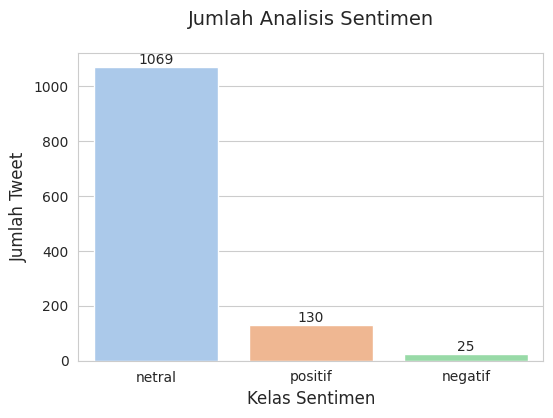

In [ ]:
# Mengimpor modul pandas sebagai pd untuk manipulasi data
import pandas as pd
# Mengimpor modul matplotlib.pyplot sebagai plt untuk plotting
import matplotlib.pyplot as plt
# Mengimpor modul seaborn sebagai sns untuk plotting yang lebih interaktif
import seaborn as sns

# Menghitung jumlah sentimen menggunakan value_counts() dari kolom 'sentiment' dalam DataFrame 'data'
sentiment_count = data['sentiment'].value_counts()

# Mengatur gaya plot menjadi 'whitegrid' menggunakan sns.set_style()
sns.set_style('whitegrid')

# Membuat subplot dengan ukuran tertentu
fig, ax = plt.subplots(figsize=(6, 4))
# Menggambar barplot menggunakan sns.barplot() dengan sumbu x sebagai indeks sentimen dan sumbu y sebagai jumlahnya
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')
# Menambahkan judul plot
plt.title('Jumlah Analisis Sentimen', fontsize=14, pad=20)
# Menambahkan label sumbu x
plt.xlabel('Kelas Sentimen', fontsize=12)
# Menambahkan label sumbu y
plt.ylabel('Jumlah Tweet', fontsize=12)

# Menambahkan anotasi untuk setiap bar di plot
for i, count in enumerate(sentiment_count.values):
    ax.text(i, count + 0.10, str(count), ha='center', va='bottom')

# Menampilkan plot
plt.show()


In [ ]:
data.to_csv('Hasil-Labelling-Data-TextBlob-14-juni.csv', encoding='utf8', index=False)

## **PAKE VADERSENTIMENT**

In [ ]:
# Mengimpor modul pandas sebagai pd untuk manipulasi data
import pandas as pd
# Mengimpor modul numpy sebagai np untuk manipulasi array dan data numerik
import numpy as np

# Mendefinisikan fungsi load_data() untuk memuat data dari file CSV
def load_data():
    # Membaca data dari file CSV yang disimpan di lokasi tertentu
    data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Kecerdasan Buatan/TUBES/preprocessing-14-juni.csv')
    # Mengembalikan DataFrame yang berisi data yang dimuat
    return data

# Memuat data dengan memanggil fungsi load_data() dan menyimpannya dalam variabel 'data'
data = load_data()

# Menampilkan 5 baris pertama dari DataFrame 'data' untuk memeriksa data yang dimuat
data.head(5)


,created_at,username,full_text,cleasing,case_folding,tokenize,Filtering/stopword removal,stemming_data,normalized_text
0,Fri May 24 06:54:07 +0000 2024,Officialkjti,Pertama kali beli jersey pabrikan Errea yang n...,Pertama kali beli jersey pabrikan Errea yang n...,pertama kali beli jersey pabrikan errea yang n...,"['pertama', 'kali', 'beli', 'jersey', 'pabrika...","['kali', 'beli', 'jersey', 'pabrikan', 'errea'...",kali beli jersey pabrikan errea ngegarap jerse...,kali beli jersey pabrikan errea ngegarap jerse...
1,Fri May 24 06:39:05 +0000 2024,Officialkjti,Tidak di 3 ini sih kabarnya kan cuma kabar tun...,Tidak di ini sih kabarnya kan cuma kabar tung...,tidak di ini sih kabarnya kan cuma kabar tung...,"['tidak', 'di', 'ini', 'sih', 'kabarnya', 'kan...","['sih', 'kabarnya', 'kabar', 'tunggu', 'aja', ...",sih kabar kabar tunggu aja juli kaya udah dium...,sih kabar kabar tunggu aja juli kaya udah dium...
2,Fri May 24 06:33:14 +0000 2024,Officialkjti,Tapi isunya persib psis trus ada beberapa lagi...,Tapi isunya persib psis trus ada beberapa lagi...,tapi isunya persib psis trus ada beberapa lagi...,"['tapi', 'isunya', 'persib', 'psis', 'trus', '...","['isunya', 'persib', 'psis', 'trus', 'pakai', ...",isu persib psis trus pakai apparel musim,isu persib psis trus pakai apparel musim
3,Fri May 24 06:28:05 +0000 2024,minfieldstore,Full interview Nunez dengan Por la Jersey: Aku...,Full interview Nunez dengan Por la Jersey Aku ...,full interview nunez dengan por la jersey aku ...,"['full', 'interview', 'nunez', 'dengan', 'por'...","['full', 'interview', 'nunez', 'por', 'la', 'j...",full interview nunez por la jersey rumah timna...,full interview nunez por la jersey rumah timna...
4,Fri May 24 05:45:31 +0000 2024,amrll_is,Buat yang mau Jersey Timnas Supporter Version ...,Buat yang mau Jersey Timnas Supporter Version ...,buat yang mau jersey timnas supporter version ...,"['buat', 'yang', 'mau', 'jersey', 'timnas', 's...","['jersey', 'timnas', 'supporter', 'version', '...",jersey timnas supporter version ori home away ...,jersey timnas supporter version ori home away ...


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1224 entries, 0 to 1223
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   created_at                  1224 non-null   object
 1   username                    1224 non-null   object
 2   full_text                   1224 non-null   object
 3   cleasing                    1224 non-null   object
 4   case_folding                1224 non-null   object
 5   tokenize                    1224 non-null   object
 6   Filtering/stopword removal  1224 non-null   object
 7   stemming_data               1223 non-null   object
 8   normalized_text             1223 non-null   object
dtypes: object(9)
memory usage: 86.2+ KB


In [ ]:
df = pd.DataFrame(data['stemming_data'])
df.head(5)

,stemming_data
0,kali beli jersey pabrikan errea ngegarap jerse...
1,sih kabar kabar tunggu aja juli kaya udah dium...
2,isu persib psis trus pakai apparel musim
3,full interview nunez por la jersey rumah timna...
4,jersey timnas supporter version ori home away ...


In [ ]:
# Menginstal modul VaderSentiment menggunakan pip
!pip install VaderSentiment

# Mengimpor kelas SentimentIntensityAnalyzer dari modul vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Inisialisasi objek SentimentIntensityAnalyzer sebagai analyser
analyser = SentimentIntensityAnalyzer()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.8 MB/s eta 0:00:00


In [ ]:
# scores = [analyser.polarity_scores(x) for x in df['stemming_data']]
# df['Compound_Score'] = [x['compound'] for x in scores]

# df.head(5)

# Mengonversi semua entri ke string dan mengganti nilai NaN dengan string kosong
df['stemming_data'] = df['stemming_data'].astype(str).fillna('')

# Menghitung skor sentimen untuk setiap teks menggunakan list comprehension
scores = [analyser.polarity_scores(str(x)) for x in df['stemming_data']]

# Mengekstrak skor komposit dari setiap kamus skor
compound_scores = [x['compound'] for x in scores]

# Menambahkan skor komposit sebagai kolom baru ke dalam DataFrame
df['Compound_Score'] = compound_scores

# Menampilkan 5 baris pertama dari DataFrame
df.head(5)


,stemming_data,Compound_Score
0,kali beli jersey pabrikan errea ngegarap jerse...,0.0000
1,sih kabar kabar tunggu aja juli kaya udah dium...,0.0000
2,isu persib psis trus pakai apparel musim,0.0000
3,full interview nunez por la jersey rumah timna...,0.0000
4,jersey timnas supporter version ori home away ...,-0.3612


In [ ]:
# Menggunakan label-based indexing untuk menentukan nilai 'Sentiments' berdasarkan nilai 'Compound_Score'
# Jika 'Compound_Score' kurang dari 0, nilai 'Sentiments' diatur menjadi 'Negatif'
df.loc[df['Compound_Score'] < 0, 'Sentiments'] = 'Negatif'

# Jika 'Compound_Score' sama dengan 0, nilai 'Sentiments' diatur menjadi 'Netral'
df.loc[df['Compound_Score'] == 0, 'Sentiments'] = 'Netral'

# Jika 'Compound_Score' lebih dari 0, nilai 'Sentiments' diatur menjadi 'Positif'
df.loc[df['Compound_Score'] > 0, 'Sentiments'] = 'Positif'

# Menampilkan 5 baris pertama dari DataFrame untuk memeriksa hasilnya
df.head(5)


,stemming_data,Compound_Score,Sentiments
0,kali beli jersey pabrikan errea ngegarap jerse...,0.0000,Netral
1,sih kabar kabar tunggu aja juli kaya udah dium...,0.0000,Netral
2,isu persib psis trus pakai apparel musim,0.0000,Netral
3,full interview nunez por la jersey rumah timna...,0.0000,Netral
4,jersey timnas supporter version ori home away ...,-0.3612,Negatif


<ipython-input-105-014b4b2e1af5>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')


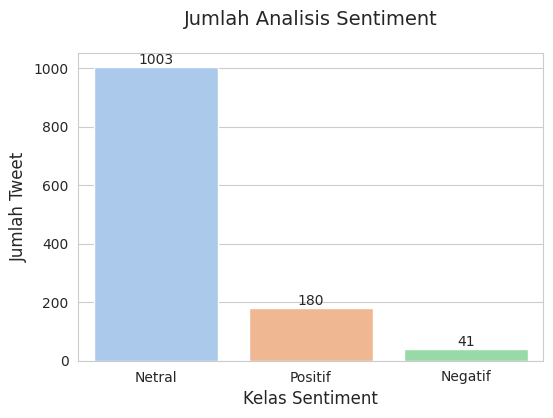

In [ ]:
# Menghitung jumlah sentimen untuk setiap kategori menggunakan value_counts() dari kolom 'Sentiments' dalam DataFrame 'df'
sentiment_count = df['Sentiments'].value_counts()

# Mengatur gaya plot menjadi 'whitegrid' menggunakan sns.set_style()
sns.set_style('whitegrid')

# Membuat subplot dengan ukuran tertentu
fig, ax = plt.subplots(figsize=(6, 4))

# Menggambar barplot menggunakan sns.barplot() dengan sumbu x sebagai indeks sentimen dan sumbu y sebagai jumlahnya
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')

# Menambahkan judul plot
plt.title('Jumlah Analisis Sentiment', fontsize=14, pad=20)

# Menambahkan label sumbu x
plt.xlabel('Kelas Sentiment', fontsize=12)

# Menambahkan label sumbu y
plt.ylabel('Jumlah Tweet', fontsize=12)

# Menambahkan anotasi untuk setiap bar di plot
for i, count in enumerate(sentiment_count.values):
    ax.text(i, count + 0.10, str(count), ha='center', va='bottom')

# Menampilkan plot
plt.show()


In [ ]:
df.to_csv('Hasil-Labelling-Data-VaderSentiment-14-juni.csv', encoding='utf8', index=False)

# **TF-IDF**

In [ ]:
!pip install pandas scikit-learn

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from tabulate import tabulate

data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Kecerdasan Buatan/TUBES/Hasil-Labelling-Data-TextBlob-14-juni.csv')
data.head(5)


,stemming_data,sentiment_score,sentiment
0,kali beli jersey pabrikan errea ngegarap jerse...,0.00,netral
1,sih kabar kabar tunggu aja juli kaya udah dium...,0.00,netral
2,isu persib psis trus pakai apparel musim,0.00,netral
3,full interview nunez por la jersey rumah timna...,0.35,positif
4,jersey timnas supporter version ori home away ...,0.00,netral


In [ ]:
# tfidf_vectorizer = TfidfVectorizer()
# tfidf_matrix = tfidf_vectorizer.fit_transform(data['stemming_data'])

# terms = tfidf_vectorizer.get_feature_names_out()
# idf = np.log(tfidf_matrix.shape[0] / (np.count_nonzero(tfidf_matrix.toarray(), axis=0) + 1))

# tfidf_df = pd.DataFrame({'term': terms, 'idf': idf})

# for i, doc in enumerate(data['stemming_data']):
#     tf = tfidf_matrix[i].toarray().flatten()
#     tfidf_df[f'tf{i}'] = tf

# tfidf_df.to_csv('hasil_tfidf-3juni.csv', index=False)

# Ganti nilai NaN di kolom 'stemming_data' dengan string kosong
data['stemming_data'] = data['stemming_data'].fillna('')

# Inisialisasi TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit dan transform data menggunakan TfidfVectorizer
tfidf_matrix = tfidf_vectorizer.fit_transform(data['stemming_data'])

# Mendapatkan istilah (fitur) dan nilai idf
terms = tfidf_vectorizer.get_feature_names_out()
idf = np.log(tfidf_matrix.shape[0] / (np.count_nonzero(tfidf_matrix.toarray(), axis=0) + 1))

# Membuat DataFrame untuk menyimpan nilai tfidf
tfidf_df = pd.DataFrame({'term': terms, 'idf': idf})

# Menghitung nilai tfidf untuk setiap dokumen dan menambahkannya ke DataFrame
for i, doc in enumerate(data['stemming_data']):
    tf = tfidf_matrix[i].toarray().flatten()
    tfidf_df[f'tf{i}'] = tf

# Simpan DataFrame ke file CSV
tfidf_df.to_csv('hasil_tfidf-3juni.csv', index=False)



<ipython-input-109-4a544f2a20b9>:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tfidf_df[f'tf{i}'] = tf
<ipython-input-109-4a544f2a20b9>:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tfidf_df[f'tf{i}'] = tf
<ipython-input-109-4a544f2a20b9>:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tfid

In [ ]:
tfidf_df.head(50)

,term,idf,tf0,tf1,tf2,tf3,tf4,tf5,tf6,tf7,...,tf1214,tf1215,tf1216,tf1217,tf1218,tf1219,tf1220,tf1221,tf1222,tf1223
0,aaaaaaaaaaa,6.416732,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
1,aamiin,6.011267,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2,aamiinn,6.416732,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3,abal,6.416732,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,abang,6.011267,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
5,abangan,6.011267,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
6,abdi,6.416732,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
7,abdnraa,6.416732,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.524144,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
8,aberdeen,6.416732,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
9,abi,6.416732,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


# **KLASIFIKASI NAIVE BAYES**

## **Import Library**

In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Kecerdasan Buatan/TUBES/Hasil-Labelling-Data-TextBlob-14-juni.csv')
dataset.head()

,stemming_data,sentiment_score,sentiment
0,kali beli jersey pabrikan errea ngegarap jerse...,0.00,netral
1,sih kabar kabar tunggu aja juli kaya udah dium...,0.00,netral
2,isu persib psis trus pakai apparel musim,0.00,netral
3,full interview nunez por la jersey rumah timna...,0.35,positif
4,jersey timnas supporter version ori home away ...,0.00,netral


In [ ]:
dataset.empty

False

## **Label Encoder**

merubah menjadi numeric 0,1,2



In [ ]:
en = LabelEncoder()

dataset['sentiment'] = en.fit_transform(dataset['sentiment'])
dataset.head()

,stemming_data,sentiment_score,sentiment
0,582,0.00,1
1,898,0.00,1
2,424,0.00,1
3,287,0.35,2
4,526,0.00,1


In [ ]:
# Mengambil semua kolom kecuali kolom terakhir sebagai fitur input (X) dalam bentuk array numpy.
x = dataset.iloc[:, :-1 ].values

# Mengambil kolom terakhir sebagai label target (Y) dalam bentuk array numpy.
y = dataset.iloc[:, -1 ].values

In [ ]:
x

array([[5.820e+02, 0.000e+00],
       [8.980e+02, 0.000e+00],
       [4.240e+02, 0.000e+00],
       ...,
       [4.000e+00, 0.000e+00],
       [1.027e+03, 0.000e+00],
       [6.250e+02, 2.500e-01]])

In [ ]:
y

array([1, 1, 1, ..., 1, 1, 2])

## **Split Data**

In [ ]:
# Membagi data menjadi set pelatihan dan pengujian dengan ukuran 80% untuk pelatihan dan 20% untuk pengujian.
x_train,x_test,y_train,y_test= train_test_split(x, y , test_size=0.2, random_state=123)

print("x_train = ", len(x_train))
print("x_test = ", len(x_test))
print("y_train = ", len(y_train))
print("y_test = ", len(y_test))

x_train =  979
x_test =  245
y_train =  979
y_test =  245


## **Pengskalaan Nilai Pada Dataset**

In [ ]:
sc = StandardScaler()
# Membuat instance dari StandardScaler untuk normalisasi fitur, yaitu mengatur mean=0 dan standar deviasi=1.

x_train = sc.fit_transform(x_train)
# Menyesuaikan skala dengan data pelatihan dan menerapkan transformasi standar (mean=0, std=1) ke x_train.

x_test = sc.transform(x_test)
# Menerapkan transformasi skala yang sama (yang diperoleh dari x_train) ke x_test.

In [ ]:
x_train

array([[-1.40028828,  2.55488925],
       [-1.4910296 , -0.20479563],
       [-1.16248346, -0.20479563],
       ...,
       [-0.15181296, -0.20479563],
       [ 0.02654066, -0.20479563],
       [ 1.5973041 , -0.20479563]])

In [ ]:
x_test

array([[-1.26886983e+00,  1.30048703e+00],
       [-4.85556002e-02, -2.04795635e-01],
       [ 1.53472388e+00, -2.04795635e-01],
       [ 1.26249994e+00, -2.04795635e-01],
       [-1.51919069e+00, -2.04795635e-01],
       [ 1.42833751e+00,  3.21326036e+00],
       [ 1.38766037e+00,  1.80224792e+00],
       [ 9.87146986e-01, -2.04795635e-01],
       [ 5.20924372e-01, -2.04795635e-01],
       [-1.12493533e+00, -2.04795635e-01],
       [-1.34083707e+00, -1.20831741e+00],
       [ 6.33568762e-01,  3.14027696e+00],
       [ 1.64217137e-01, -2.04795635e-01],
       [-1.11867731e+00, -2.04795635e-01],
       [-1.14996741e+00, -2.04795635e-01],
       [-7.98457086e-02,  6.69441658e+00],
       [ 5.11537339e-01, -2.04795635e-01],
       [-3.36424597e-01, -2.04795635e-01],
       [-2.03945027e-02,  2.55488925e+00],
       [-1.11867731e+00, -2.04795635e-01],
       [-1.48790058e+00, -2.04795635e-01],
       [-1.27512785e+00, -2.04795635e-01],
       [ 6.80503924e-01, -2.04795635e-01],
       [ 6.

In [ ]:
y_train

array([2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 0,
       1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 2, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 2, 1, 1, 1, 1, 2, 2,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 0, 1, 1, 1, 1, 1, 1, 1, 2, 1,
       1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 2, 2,
       1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1,

In [ ]:
y_test

array([2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 0, 2, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 0, 1, 1, 0, 1, 2, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1])

## **TRAINING MODEL MENGGUNAKAN KLASIFIKASI NAIVE BAYES**

In [ ]:
# Membuat instance dari model Gaussian Naive Bayes, yang digunakan untuk klasifikasi berdasarkan distribusi normal.
classifier = GaussianNB()

# Melatih model Gaussian Naive Bayes dengan data pelatihan (x_train, y_train) untuk mempelajari pola dan melakukan prediksi.
classifier.fit(x_train,y_train)



GaussianNB()

## **Hasil Prediksi**

In [ ]:
# Menggunakan model Gaussian Naive Bayes yang telah dilatih untuk memprediksi label dari data pengujian (x_test).
y_pred = classifier.predict(x_test)

# Menampilkan prediksi label untuk data pengujian.
y_pred

array([2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 0, 2, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 0, 1, 1, 2, 1, 2, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1])

## **Prediksi Probabilitas**

In [ ]:
# Menghasilkan probabilitas prediksi untuk setiap kelas pada data pengujian (x_test).
classifier.predict_proba(x_test)

array([[2.57988837e-02, 0.00000000e+00, 9.74201116e-01],
       [1.71190351e-07, 9.99999312e-01, 5.16541481e-07],
       [1.96607802e-07, 9.99999065e-01, 7.37963579e-07],
       [1.95739926e-07, 9.99999105e-01, 6.99577080e-07],
       [1.17959337e-07, 9.99999546e-01, 3.35679810e-07],
       [2.32082912e-03, 0.00000000e+00, 9.97679171e-01],
       [1.02341653e-02, 0.00000000e+00, 9.89765835e-01],
       [1.93277220e-07, 9.99999146e-01, 6.60566907e-07],
       [1.85659729e-07, 9.99999220e-01, 5.94831015e-07],
       [1.33383140e-07, 9.99999486e-01, 3.80359444e-07],
       [7.51277466e-01, 0.00000000e+00, 2.48722534e-01],
       [2.78969600e-03, 0.00000000e+00, 9.97210304e-01],
       [1.77188268e-07, 9.99999277e-01, 5.45425507e-07],
       [1.33625381e-07, 9.99999485e-01, 3.81093434e-07],
       [1.32412929e-07, 9.99999490e-01, 3.77431033e-07],
       [1.31412629e-03, 0.00000000e+00, 9.98685874e-01],
       [1.85464518e-07, 9.99999221e-01, 5.93518163e-07],
       [1.62123801e-07, 9.99999

## **EVALUASI MENGGUNAKAN CONFUSION MATRIX**

In [ ]:
# Membuat confusion matrix untuk membandingkan prediksi (y_pred) dengan nilai sebenarnya (y_test).
cm = confusion_matrix(y_test,y_pred)

# yang menunjukkan jumlah prediksi benar dan salah untuk setiap kelas.
print(cm)

[[  4   0   1]
 [  0 213   0]
 [  0   0  27]]


## **EVALUASI MENGGUNAKAN CLASSIFICATION REPORT**

In [ ]:
# Menghasilkan laporan klasifikasi untuk setiap kelas berdasarkan prediksi (y_pred) dan label sebenarnya (y_test).
akurasi = classification_report(y_test,y_pred)

print(akurasi)

              precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       1.00      1.00      1.00       213
           2       0.96      1.00      0.98        27

    accuracy                           1.00       245
   macro avg       0.99      0.93      0.96       245
weighted avg       1.00      1.00      1.00       245



## **ACCURACY SCORE**

In [ ]:
akurasi = accuracy_score(y_test,y_pred)
print("Tingkat Akurasi: %d persen"%(akurasi*100))

Tingkat Akurasi: 99 persen


In [ ]:
ydata = pd.DataFrame()
ydata['y_test'] = pd.DataFrame(y_test)
ydata['y_pred'] = pd.DataFrame(y_pred)
ydata

,y_test,y_pred
0,2,2
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
240,1,1
241,1,1
242,1,1
243,1,1


In [ ]:
ydata.to_excel('dataactualpred.xlsx', index=False)

In [ ]:
# ydata = pd.DataFrame()
# ydata = ['y_test'] = pd.DataFrame(y_test)
# ydata = ['y_pred'] = pd.DataFrame(y_pred)
# ydata

# ydata = pd.DataFrame({
#     'y_test': y_test,
#     'y_pred': y_pred
# })

# # Step 3: Define a function to categorize predictions
# def categorize_prediction(value):
#     if value > 0:
#         return 'Positive'
#     elif value < 0:
#         return 'Negative'
#     else:
#         return 'Neutral'

# # Step 4: Apply the categorization function to both y_test and y_pred
# ydata['y_test_label'] = ydata['y_test'].apply(categorize_prediction)
# ydata['y_pred_label'] = ydata['y_pred'].apply(categorize_prediction)

# # Display the DataFrame with the new labels
# print(ydata)

# **CONFUSION MATRIX**

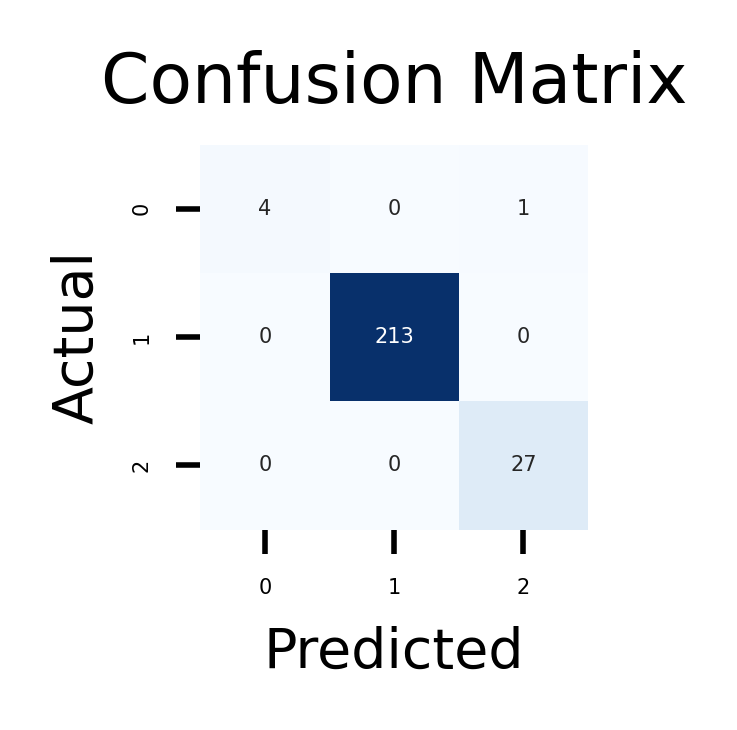

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix



plt.figure(figsize=(1, 1), dpi=500)
plt.rcParams['font.size'] = 3

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)

plt.xlabel("Predicted", fontsize=8)
plt.ylabel("Actual", fontsize=8)
plt.title("Confusion Matrix", fontsize=10)
plt.show()
